# Fractional Brownian Motion (fBM)

Fractional Brownian motion generalizes standard Brownian motion by introducing 
the **Hurst parameter** $H \in (0, 1)$, which controls the correlation structure of increments.

## Definition

A fractional Brownian motion $B_H(t)$ is a continuous Gaussian process with:

1. **$B_H(0) = 0$**
2. **Mean zero**: $\mathbb{E}[B_H(t)] = 0$
3. **Covariance function**:

$$\text{Cov}(B_H(s), B_H(t)) = \frac{1}{2}\left(|s|^{2H} + |t|^{2H} - |s-t|^{2H}\right)$$

## The Hurst Parameter $H$

| $H$ | Behavior | Increment Correlation |
|-----|----------|---------------------|
| **$H < 0.5$** | Anti-persistent | Negative — up tends to follow down |
| **$H = 0.5$** | Standard BM | Zero — independent increments |
| **$H > 0.5$** | Persistent / Long memory | Positive — trends tend to continue |

> **Key insight:** Unlike standard BM, fBM increments are **not independent** (except when $H = 0.5$). 
> The process has **memory** — the past influences the future.


## Variance of Increments

For standard BM: $\text{Var}(W(t+h) - W(t)) = h$

For fBM:

$$\boxed{\text{Var}(B_H(t+h) - B_H(t)) = h^{2H}}$$

This is the **defining property** of fBM. The variance scales as a power law with exponent $2H$.

### Examples

| $H$ | Variance scaling | Interpretation |
|-----|-----------------|----------------|
| $H = 0.1$ | $h^{0.2}$ | Very rough paths, high frequency noise dominates |
| $H = 0.5$ | $h^{1}$ | Standard BM scaling |
| $H = 0.9$ | $h^{1.8}$ | Very smooth paths, almost differentiable |

## Autocorrelation of Increments

For increments $\Delta B_i = B_H(t_{i+1}) - B_H(t_i)$ with spacing $\Delta t$:

$$\rho(k) = \frac{\text{Cov}(\Delta B_i, \Delta B_{i+k})}{\text{Var}(\Delta B_i)} = \frac{1}{2}\left(|k+1|^{2H} + |k-1|^{2H} - 2|k|^{2H}\right)$$

### Key Observations

- **$H = 0.5$**: $\rho(k) = 0$ for all $k \geq 1$ (independent increments)
- **$H > 0.5$**: $\rho(k) > 0$, decaying slowly as $k^{-2(1-H)}$ — **long memory**
- **$H < 0.5$**: $\rho(k) < 0$, oscillating — **anti-persistence**

For $H = 0.7$: $\rho(1) \approx 0.32$, $\rho(2) \approx 0.19$, $\rho(10) \approx 0.05$ — 
increments remain correlated even at long lags!


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def simulate_fbm_chol(T=1.0, N=1000, H=0.5, n_paths=1, seed=None):
    """
    Simulate fractional Brownian motion using Cholesky decomposition.
    
    The increments (fractional Gaussian noise) have a Toeplitz covariance matrix.
    We generate them via Cholesky, then cumsum to get the path.
    
    Note: This is O(N^3). For large N, use the Davies-Harte method (FFT-based).
    """
    if seed is not None:
        np.random.seed(seed)
    
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # Covariance of increments: gamma(k) = Cov(dB_i, dB_{i+k})
    # For fBM with spacing dt:
    # gamma(k) = 0.5 * dt^(2H) * (|k+1|^(2H) + |k-1|^(2H) - 2|k|^(2H))
    k = np.arange(N)
    gamma = 0.5 * (np.abs(k + 1)**(2*H) + np.abs(k - 1)**(2*H) - 2*np.abs(k)**(2*H))
    
    # Build Toeplitz covariance matrix
    cov_matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            cov_matrix[i, j] = gamma[abs(i - j)]
    
    # Scale by dt^(2H)
    cov_matrix *= dt**(2*H)
    
    # Cholesky decomposition (add small regularization for numerical stability)
    L = np.linalg.cholesky(cov_matrix + 1e-10 * np.eye(N))
    
    # Generate correlated increments
    Z = np.random.normal(0, 1, size=(n_paths, N))
    dB = np.einsum('ij,nj->ni', L, Z)
    
    # Cumulative sum to get fBM
    B = np.zeros((n_paths, N + 1))
    B[:, 1:] = np.cumsum(dB, axis=1)
    
    return t, B

# Quick test
t, B = simulate_fbm_chol(T=1.0, N=500, H=0.7, n_paths=3, seed=42)
print(f"Shape: {B.shape}")
print(f"B(0) = {B[:, 0]}")
print(f"Var(B(1)) = {np.var(B[:, -1]):.4f} (theory: 1.0)")


Shape: (3, 501)
B(0) = [0. 0. 0.]
Var(B(1)) = 1.0032 (theory: 1.0)


## The Simulation Method Explained

### Step 1: Fractional Gaussian Noise (fGN)

fBM is the **cumulative sum** of fractional Gaussian noise — correlated Gaussian increments.

### Step 2: Covariance Structure of Increments

For equally spaced increments with step $\Delta t$:

$$\text{Cov}(\Delta B_i, \Delta B_j) = \frac{(\Delta t)^{2H}}{2}\left(|k+1|^{2H} + |k-1|^{2H} - 2|k|^{2H}\right)$$

where $k = |i-j|$.

This is a **Toeplitz matrix** (constant along diagonals), which arises from the 
stationarity of fBM increments.

### Step 3: Cholesky Decomposition

$$\Sigma = L \cdot L^T$$

Then $\Delta \mathbf{B} = L \cdot \mathbf{Z}$ where $\mathbf{Z} \sim \mathcal{N}(0, I)$.

### Step 4: Cumulative Sum

$$B_H(t_n) = \sum_{i=1}^{n} \Delta B_i$$

> **Computational note:** Cholesky is $O(N^3)$. For $N > 2000$, use the 
> **Davies-Harte method** which uses FFT and is $O(N \log N)$.


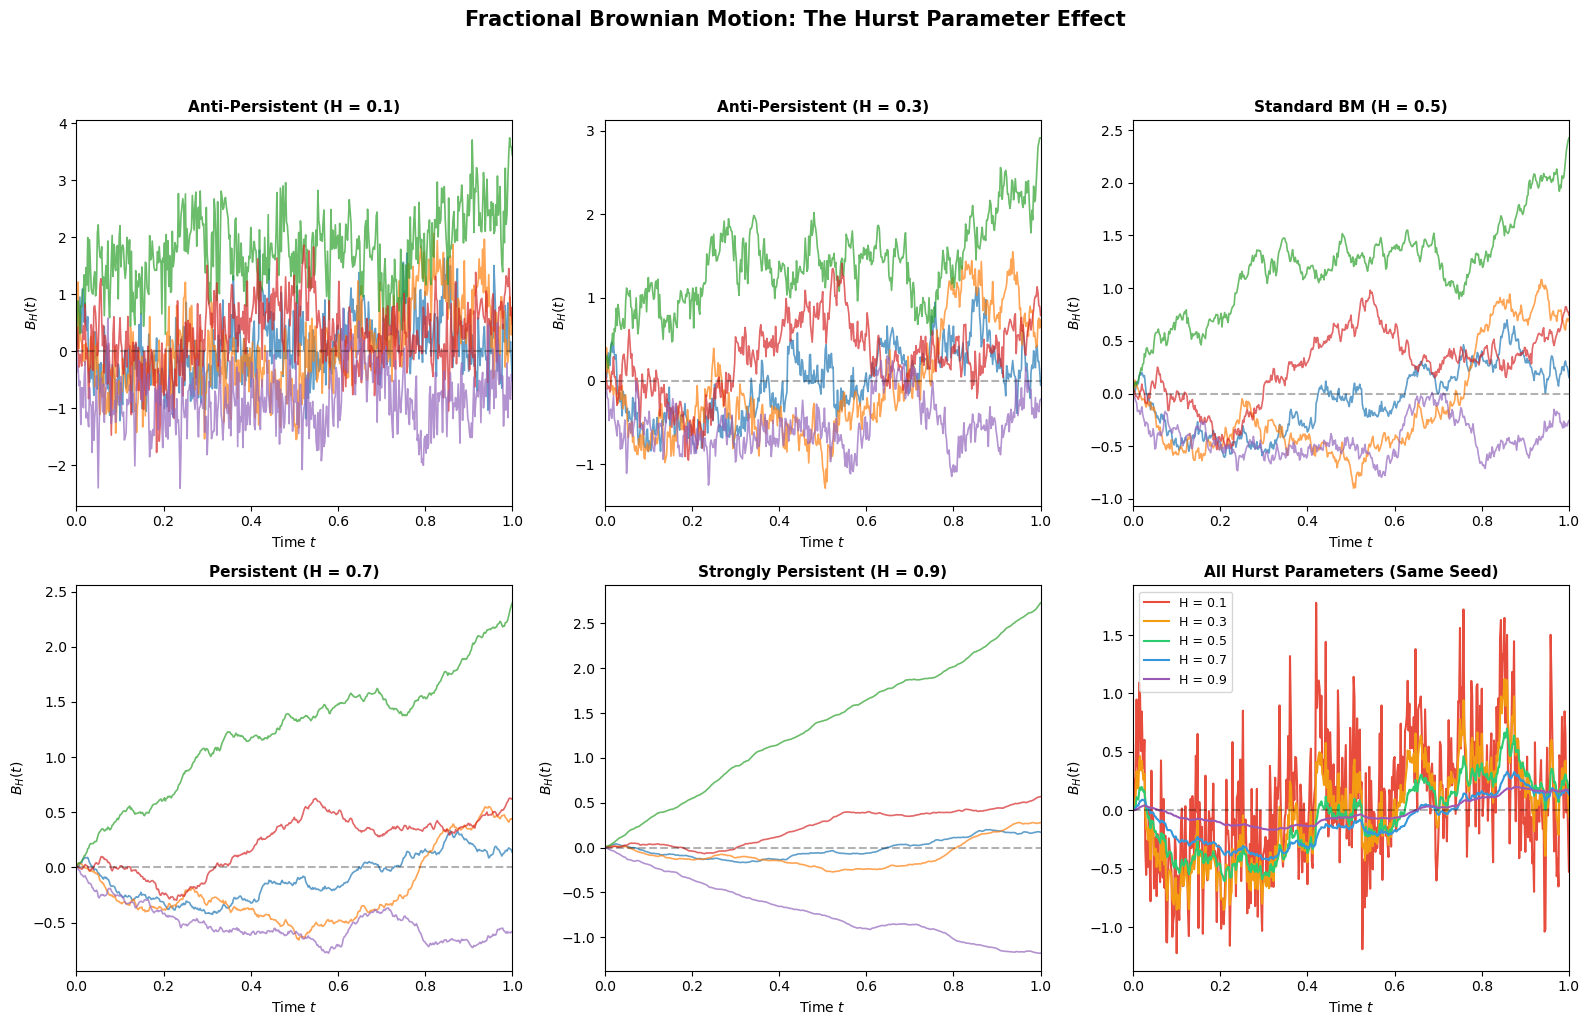

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Fractional Brownian Motion: The Hurst Parameter Effect', 
             fontsize=15, fontweight='bold', y=1.02)

H_values = [0.1, 0.3, 0.5, 0.7, 0.9]
titles = ['Anti-Persistent (H = 0.1)', 'Anti-Persistent (H = 0.3)', 
          'Standard BM (H = 0.5)', 'Persistent (H = 0.7)', 
          'Strongly Persistent (H = 0.9)']
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6']

for idx, (H, title, color) in enumerate(zip(H_values, titles, colors)):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    t, B = simulate_fbm_chol(T=1.0, N=500, H=H, n_paths=5, seed=42)
    
    for i in range(5):
        ax.plot(t, B[i], alpha=0.7, linewidth=1.2)
    
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time $t$')
    ax.set_ylabel('$B_H(t)$')
    ax.set_xlim(0, 1)

# All H overlaid
ax = axes[1, 2]
for H, color in zip(H_values, colors):
    t, B = simulate_fbm_chol(T=1.0, N=500, H=H, n_paths=1, seed=42)
    ax.plot(t, B[0], color=color, linewidth=1.5, label=f'H = {H}')

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_title('All Hurst Parameters (Same Seed)', fontsize=11, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_ylabel('$B_H(t)$')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


## The Signature of Long Memory

The autocorrelation of fBM increments reveals the Hurst parameter:

$$\rho(k) = \frac{1}{2}\left(|k+1|^{2H} + |k-1|^{2H} - 2|k|^{2H}\right)$$

### For $H = 0.7$ (Persistent)
- $\rho(1) \approx 0.32$ — if the last increment was positive, the next likely is too
- $\rho(10) \approx 0.05$ — correlation persists even at lag 10
- **Decay rate**: $\rho(k) \sim k^{-0.6}$ (slow, power-law decay)

### For $H = 0.3$ (Anti-Persistent)
- $\rho(1) \approx -0.22$ — if the last increment was positive, the next likely is negative
- The process **mean-reverts** at short timescales
- **Decay rate**: $\rho(k) \sim k^{-1.4}$ (faster decay, but oscillating)

### For $H = 0.5$ (Standard BM)
- $\rho(k) = 0$ for all $k \geq 1$
- No memory — the Markov property

> **Finance intuition:** $H \approx 0.1$ for volatility means volatility is extremely rough — 
> it changes direction constantly. $H \approx 0.4$ for stock returns means slight mean reversion.


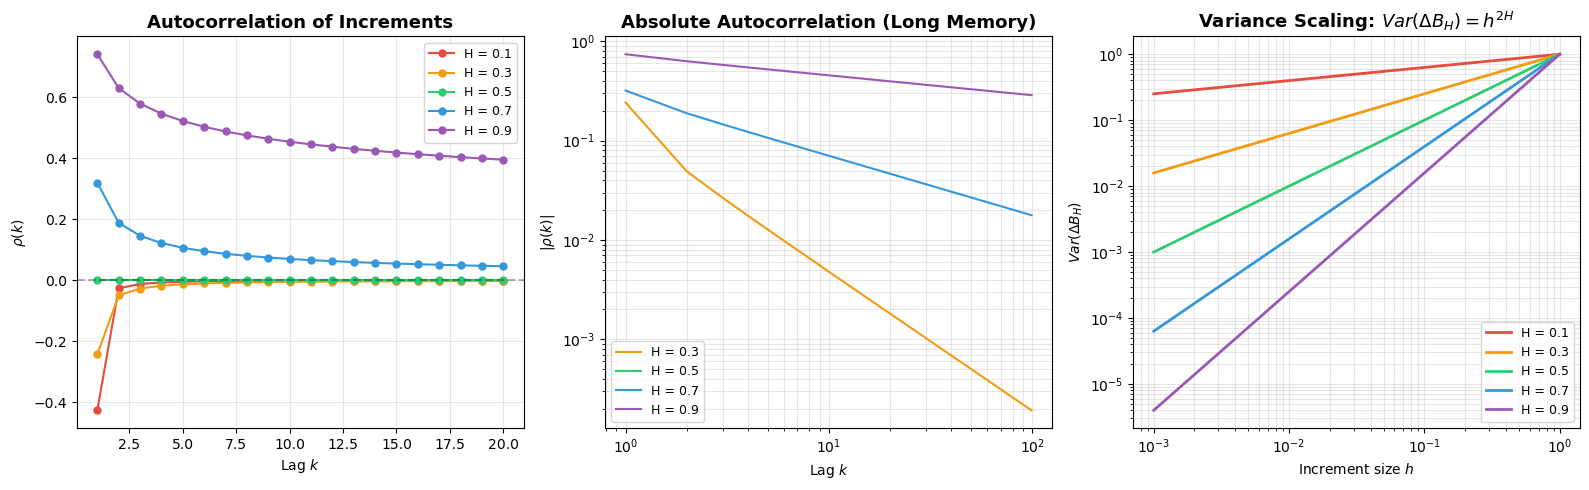

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Left: Autocorrelation of increments ---
ax = axes[0]
H_values = [0.1, 0.3, 0.5, 0.7, 0.9]
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6']
lags = np.arange(1, 21)

for H, color in zip(H_values, colors):
    rho = 0.5 * (np.abs(lags + 1)**(2*H) + np.abs(lags - 1)**(2*H) - 2*np.abs(lags)**(2*H))
    ax.plot(lags, rho, 'o-', color=color, markersize=5, linewidth=1.5, label=f'H = {H}')

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_title('Autocorrelation of Increments', fontsize=13, fontweight='bold')
ax.set_xlabel('Lag $k$')
ax.set_ylabel('$\\rho(k)$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Middle: Long memory decay (log-log) ---
ax = axes[1]
lags_long = np.arange(1, 100)
for H, color in zip([0.3, 0.5, 0.7, 0.9], ['#f39c12', '#2ecc71', '#3498db', '#9b59b6']):
    rho_long = 0.5 * (np.abs(lags_long + 1)**(2*H) + np.abs(lags_long - 1)**(2*H) - 2*np.abs(lags_long)**(2*H))
    ax.loglog(lags_long, np.abs(rho_long), color=color, linewidth=1.5, label=f'H = {H}')

ax.set_title('Absolute Autocorrelation (Long Memory)', fontsize=13, fontweight='bold')
ax.set_xlabel('Lag $k$')
ax.set_ylabel('$|\\rho(k)|$')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# --- Right: Variance scaling ---
ax = axes[2]
h_values = np.logspace(-3, 0, 50)
for H, color in zip(H_values, colors):
    var_scaling = h_values**(2*H)
    ax.loglog(h_values, var_scaling, color=color, linewidth=2, label=f'H = {H}')

ax.set_title('Variance Scaling: $Var(\\Delta B_H) = h^{2H}$', fontsize=13, fontweight='bold')
ax.set_xlabel('Increment size $h$')
ax.set_ylabel('$Var(\\Delta B_H)$')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()


## Application 1: Rough Volatility Models

Recent research (Gatheral, Jaisson, Rosenbaum 2018) shows that realized volatility 
in financial markets is **extremely rough**, with $H \approx 0.1$.

### The Model

$$\sigma(t) = \sigma_0 \exp\left(\nu B_H(t) - \frac{1}{2}\nu^2 t^{2H}\right)$$

where $B_H(t)$ is fBM with $H \approx 0.1$.

### Why Rough Volatility?

1. **Empirical evidence**: Log-volatility time series has $H \approx 0.1$ across all assets
2. **Microstructure**: High-frequency trading creates jagged volatility paths
3. **Better fit**: Rough models fit option smiles better than classical Heston

### Visual Difference

- **$H = 0.1$**: Volatility looks like white noise — extremely spiky
- **$H = 0.5$**: Volatility is a standard BM — moderately smooth
- **$H = 0.9$**: Volatility is almost a straight line — very smooth
- 

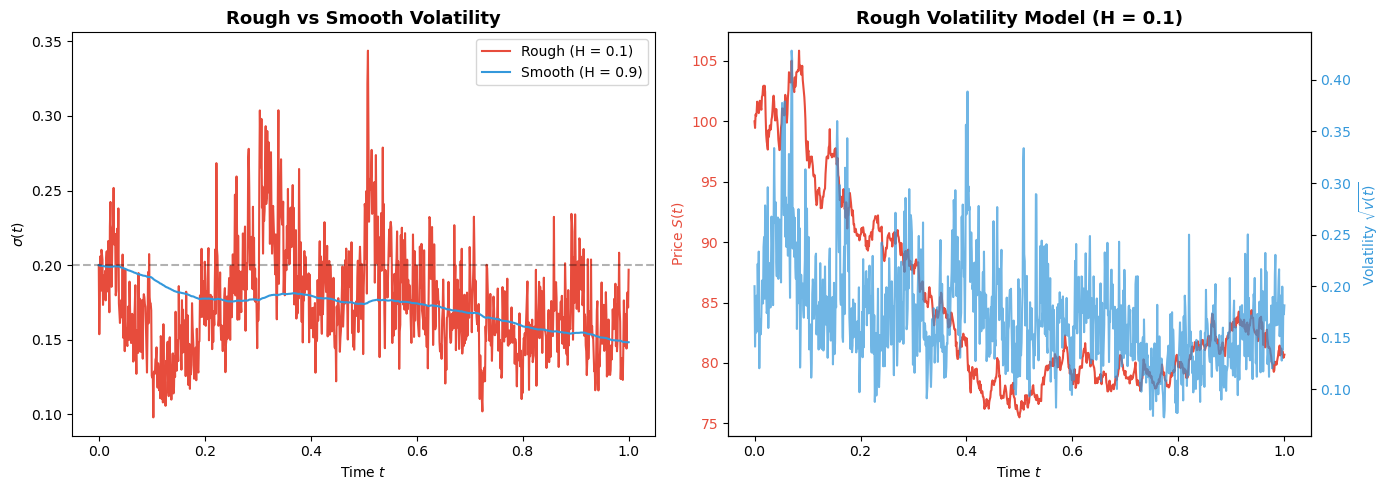

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Rough vs smooth volatility paths ---
ax = axes[0]
np.random.seed(100)
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N + 1)

sigma_0, nu = 0.2, 0.3

t_vol, B_rough = simulate_fbm_chol(T=T, N=N, H=0.1, n_paths=1, seed=100)
t_vol, B_smooth = simulate_fbm_chol(T=T, N=N, H=0.9, n_paths=1, seed=100)

sigma_rough = sigma_0 * np.exp(nu * B_rough[0])
sigma_smooth = sigma_0 * np.exp(nu * B_smooth[0])

ax.plot(t, sigma_rough, color='#e74c3c', linewidth=1.5, label='Rough (H = 0.1)')
ax.plot(t, sigma_smooth, color='#3498db', linewidth=1.5, label='Smooth (H = 0.9)')
ax.axhline(y=sigma_0, color='black', linestyle='--', alpha=0.3)
ax.set_title('Rough vs Smooth Volatility', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_ylabel('$\\sigma(t)$')
ax.legend(fontsize=10)

# --- Right: Rough Heston-like stock price model ---
ax = axes[1]
np.random.seed(400)
S0, mu, v0, nu = 100, 0.05, 0.04, 1.0

# fBM for volatility
t_fbm, B_H = simulate_fbm_chol(T=T, N=N, H=0.1, n_paths=1, seed=400)
v = v0 * np.exp(nu * B_H[0] - 0.5 * nu**2 * t**(2*0.1))
v = np.maximum(v, 1e-6)

# Price path
dW = np.random.normal(0, np.sqrt(dt), N)
S = np.zeros(N + 1)
S[0] = S0
for i in range(N):
    S[i+1] = S[i] + mu * S[i] * dt + np.sqrt(v[i]) * S[i] * dW[i]

ax.plot(t, S, color='#e74c3c', linewidth=1.5, label='Stock price')
ax2 = ax.twinx()
ax2.plot(t, np.sqrt(v), color='#3498db', linewidth=1.5, alpha=0.7, label='Volatility')
ax.set_title('Rough Volatility Model (H = 0.1)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Price $S(t)$', color='#e74c3c')
ax2.set_ylabel('Volatility $\\sqrt{v(t)}$', color='#3498db')
ax.tick_params(axis='y', labelcolor='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#3498db')

plt.tight_layout()
plt.show()


## Application 2: Estimating the Hurst Parameter

How do we know if a time series is generated by fBM? We estimate $H$.

### Method 1: Variance Scaling (Log-Log Regression)

For fBM: $\text{Var}(B_H(t+h) - B_H(t)) = h^{2H}$

Take logs: $\ln(\text{Var}) = 2H \cdot \ln(h) + \text{const}$

Fit a line to $(\ln h, \ln \text{Var})$ — the slope is $2H$.

### Method 2: R/S Analysis (Rescaled Range)

For a time series $X_1, \ldots, X_n$:

1. Compute mean-adjusted cumulative sum: $Y_k = \sum_{i=1}^{k} (X_i - \bar{X})$
2. Range: $R_n = \max_k Y_k - \min_k Y_k$
3. Standard deviation: $S_n = \sqrt{\frac{1}{n}\sum (X_i - \bar{X})^2}$
4. R/S statistic: $(R/S)_n \sim n^H$

Fit $\ln(R/S)$ vs $\ln(n)$ — slope is $H$.

### Interpretation of Estimated H

| Estimated H | Interpretation |
|-------------|----------------|
| $H \approx 0.5$ | Random walk / efficient market |
| $H > 0.5$ | Trending / momentum (persistent) |
| $H < 0.5$ | Mean-reverting / anti-persistent |


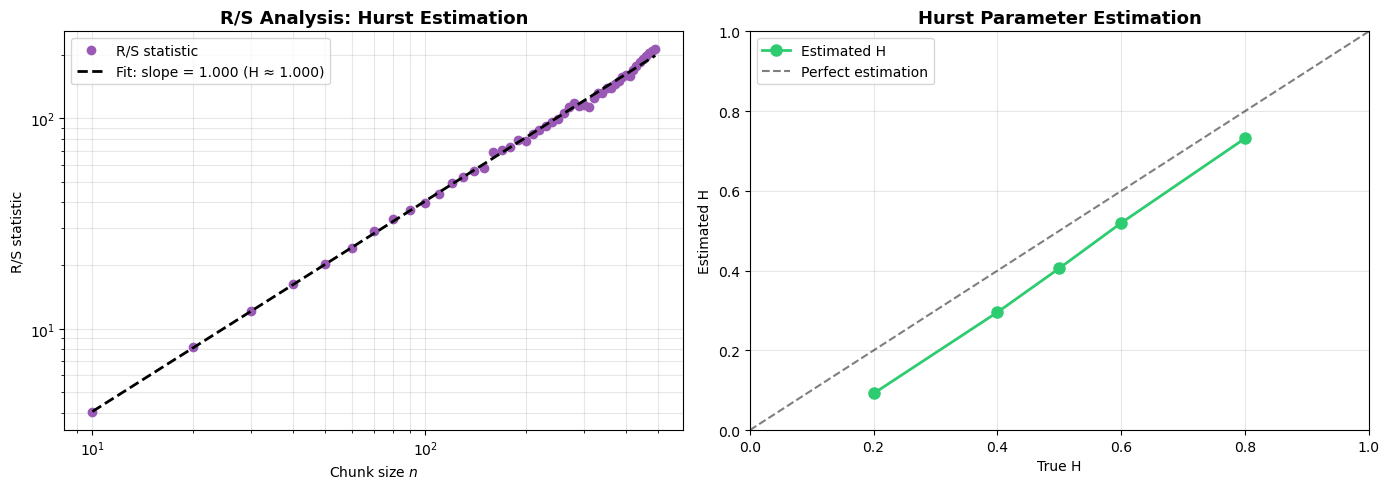

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: R/S Analysis ---
ax = axes[0]
np.random.seed(200)

# Generate fBM with known H=0.7
t, B_true = simulate_fbm_chol(T=1.0, N=2000, H=0.7, n_paths=1, seed=200)
B = B_true[0]

n_max = 500
n_values = np.arange(10, n_max, 10)
rs_values = []

for n in n_values:
    n_chunks = len(B) // n
    rs_chunks = []
    for i in range(n_chunks):
        chunk = B[i*n:(i+1)*n]
        mean_chunk = np.mean(chunk)
        cumdev = np.cumsum(chunk - mean_chunk)
        R = np.max(cumdev) - np.min(cumdev)
        S = np.std(chunk)
        if S > 0:
            rs_chunks.append(R / S)
    rs_values.append(np.mean(rs_chunks))

ax.loglog(n_values, rs_values, 'o', color='#9b59b6', markersize=6, label='R/S statistic')
log_n = np.log(n_values)
log_rs = np.log(rs_values)
slope, intercept = np.polyfit(log_n, log_rs, 1)
ax.loglog(n_values, np.exp(intercept) * n_values**slope, 'k--', linewidth=2, 
          label=f'Fit: slope = {slope:.3f} (H ≈ {slope:.3f})')
ax.set_title('R/S Analysis: Hurst Estimation', fontsize=13, fontweight='bold')
ax.set_xlabel('Chunk size $n$')
ax.set_ylabel('R/S statistic')
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

# --- Right: Variance scaling estimator ---
ax = axes[1]
np.random.seed(300)
H_true_list = [0.2, 0.4, 0.5, 0.6, 0.8]
H_estimated = []

for H_true in H_true_list:
    t, B_test = simulate_fbm_chol(T=1.0, N=1000, H=H_true, n_paths=1, seed=300)
    B = B_test[0]
    
    h_list = [1, 2, 5, 10, 20, 50]
    vars_h = []
    for h in h_list:
        incrs = B[h::h] - B[:-h:h]
        vars_h.append(np.var(incrs))
    
    log_h = np.log(np.array(h_list) / 1000)
    log_var = np.log(vars_h)
    H_est = np.polyfit(log_h, log_var, 1)[0] / 2
    H_estimated.append(H_est)

ax.plot(H_true_list, H_estimated, 'o-', color='#2ecc71', markersize=8, linewidth=2, 
        label='Estimated H')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Perfect estimation')
ax.set_title('Hurst Parameter Estimation', fontsize=13, fontweight='bold')
ax.set_xlabel('True H')
ax.set_ylabel('Estimated H')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


## Application 3: Visualizing Roughness

### Zoomed View

When you zoom in on fBM paths:

- **$H = 0.1$**: The path looks just as jagged at all scales (fractal-like)
- **$H = 0.9$**: The path looks smoother when zoomed in

This is related to the **Hölder continuity**: fBM paths are $H$-Hölder continuous.

### Fractional Gaussian Noise (fGN)

The increments $\Delta B_H$ form a stationary process called fractional Gaussian noise:

- **$H = 0.1$**: Large oscillations — the series constantly changes sign
- **$H = 0.7$**: Smaller oscillations — trends persist for many steps

> **Trading intuition:** If volatility has $H \approx 0.1$, then volatility clustering 
> happens at very short timescales. A volatility spike is immediately followed by 
> another spike in the opposite direction — making it extremely hard to predict.


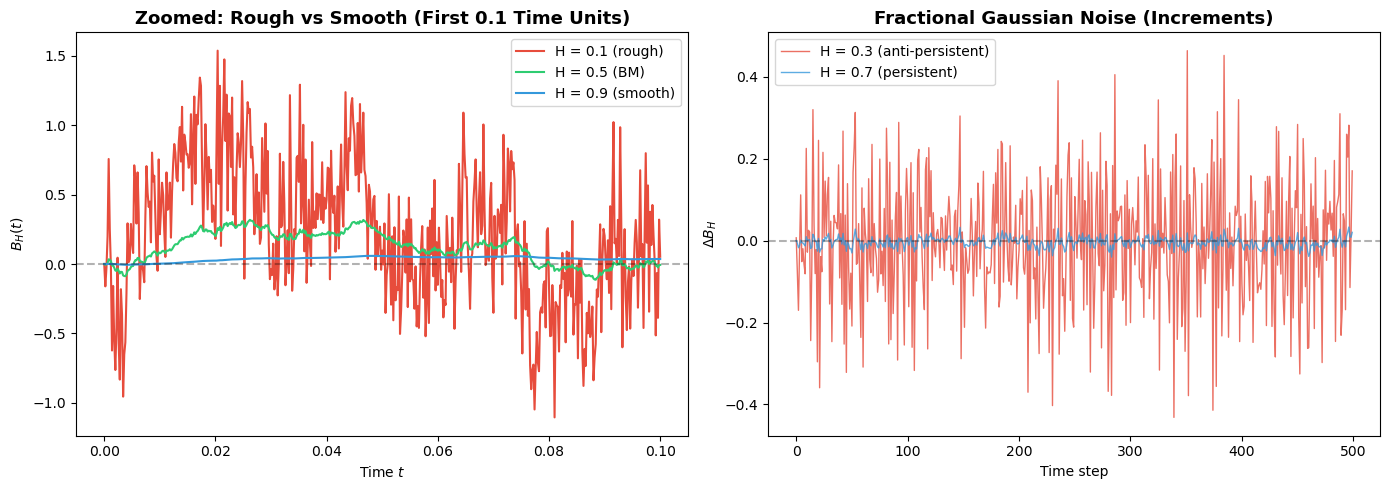

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Zoomed comparison ---
ax = axes[0]
np.random.seed(500)
t_zoom, B_rough_z = simulate_fbm_chol(T=0.1, N=500, H=0.1, n_paths=1, seed=500)
t_zoom, B_bm_z = simulate_fbm_chol(T=0.1, N=500, H=0.5, n_paths=1, seed=500)
t_zoom, B_smooth_z = simulate_fbm_chol(T=0.1, N=500, H=0.9, n_paths=1, seed=500)

ax.plot(t_zoom, B_rough_z[0], color='#e74c3c', linewidth=1.5, label='H = 0.1 (rough)')
ax.plot(t_zoom, B_bm_z[0], color='#2ecc71', linewidth=1.5, label='H = 0.5 (BM)')
ax.plot(t_zoom, B_smooth_z[0], color='#3498db', linewidth=1.5, label='H = 0.9 (smooth)')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_title('Zoomed: Rough vs Smooth (First 0.1 Time Units)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_ylabel('$B_H(t)$')
ax.legend(fontsize=10)

# --- Right: Fractional Gaussian Noise ---
ax = axes[1]
np.random.seed(600)
N_fgn = 500
t_fgn, B_fgn = simulate_fbm_chol(T=1.0, N=N_fgn, H=0.3, n_paths=1, seed=600)
fgn_rough = np.diff(B_fgn[0])
t_fgn, B_fgn2 = simulate_fbm_chol(T=1.0, N=N_fgn, H=0.7, n_paths=1, seed=600)
fgn_smooth = np.diff(B_fgn2[0])

ax.plot(fgn_rough, color='#e74c3c', linewidth=1, alpha=0.8, label='H = 0.3 (anti-persistent)')
ax.plot(fgn_smooth, color='#3498db', linewidth=1, alpha=0.8, label='H = 0.7 (persistent)')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_title('Fractional Gaussian Noise (Increments)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time step')
ax.set_ylabel('$\\Delta B_H$')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


## Complete Formula Reference

### Covariance Function
$$\text{Cov}(B_H(s), B_H(t)) = \frac{1}{2}\left(|s|^{2H} + |t|^{2H} - |s-t|^{2H}\right)$$

### Variance of Increments
$$\text{Var}(B_H(t+h) - B_H(t)) = h^{2H}$$

### Autocorrelation of Increments
$$\rho(k) = \frac{1}{2}\left(|k+1|^{2H} + |k-1|^{2H} - 2|k|^{2H}\right)$$

### Hölder Continuity
fBM paths are almost surely $H$-Hölder continuous:
$$|B_H(t) - B_H(s)| \leq C |t-s|^H$$

### Special Cases
| $H$ | Process | Properties |
|-----|---------|------------|
| $H = 0.5$ | Standard BM | Independent increments, Markov |
| $H = 1$ | Straight line | Perfectly correlated, deterministic |
| $H \to 0$ | White noise | Completely uncorrelated path |

### Simulation Complexity
| Method | Complexity | Max N |
|--------|-----------|-------|
| Cholesky | $O(N^3)$ | ~2,000 |
| Davies-Harte (FFT) | $O(N \log N)$ | ~1,000,000 |
